# BB84 QKD — Adversarial Security Analysis
### From Eve's Perspective

**Author:** Harvi Zakhir  
**Repository:** qkd-attack-analysis  
**Reference:** Bennett & Brassard (1984), Huttner et al. (1995), Lo et al. (2005)

---

This notebook analyzes BB84 Quantum Key Distribution from the attacker's perspective.

Three attacks are modeled, in order of sophistication:

| Attack | Info gained | QBER cost | Detectable? |
|--------|------------|-----------|-------------|
| Full intercept-resend | ~50% per bit | +25% | Yes — always |
| Partial intercept (η) | ~η×50% | +η×25% | Depends on threshold |
| PNS (weak coherent pulse) | Free on n≥2 pulses | Zero | Not without decoy states |

**Core finding:** Theoretical BB84 security breaks down when Alice uses a realistic laser source (weak coherent pulse). The PNS attack exploits multi-photon pulses to gain information silently, with zero detectable QBER increase.


In [9]:
import sys, os
sys.path.insert(0, os.path.abspath(''))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from qkd import BB84
from attacks import InterceptResend, PartialIntercept, PNS
from analysis import sweep_partial_intercept, sweep_mu, detection_analysis

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
print("Environment ready.")


Environment ready.


## 1. Quick Protocol Demo

Three scenarios side by side: no Eve, full intercept-resend, PNS on real hardware.


In [10]:
N = 5000

print("=" * 52)
print("SCENARIO 1 — No Eve  (noise=2%)")
print("=" * 52)
r = BB84(n_photons=N, noise=0.02).run()
print(r.summary())

print()
print("=" * 52)
print("SCENARIO 2 — Full intercept-resend")
print("=" * 52)
r = BB84(n_photons=N, noise=0.00).run(eve=InterceptResend())
print(r.summary())
print(f"  Theory: QBER = 25%  Got: {r.qber:.1%}")

print()
print("=" * 52)
print("SCENARIO 3 — PNS on weak coherent pulse (mu=0.1)")
print("=" * 52)
r = BB84(n_photons=N, noise=0.01, use_wcp=True, mu=0.1).run(eve=PNS(mu=0.1))
print(r.summary())
print(f"  Theoretical info leak: {PNS.information_per_key_bit(0.1):.3%} bits/bit")
print("  Note: QBER is unchanged — PNS is completely silent")


SCENARIO 1 — No Eve  (noise=2%)
Photons sent:       5000
Sifted key length:  2535
Sift ratio:         50.7%
QBER:               1.026%
Eve intercepted:    0 (0.0%)
Eve information:    0.000 bits/bit

SCENARIO 2 — Full intercept-resend
Photons sent:       5000
Sifted key length:  2450
Sift ratio:         49.0%
QBER:               23.878%
Eve intercepted:    5000 (100.0%)
Eve information:    0.197 bits/bit
  Theory: QBER = 25%  Got: 23.9%

SCENARIO 3 — PNS on weak coherent pulse (mu=0.1)
Photons sent:       5000
Sifted key length:  2501
Sift ratio:         50.0%
QBER:               0.320%
Eve intercepted:    26 (0.5%)
Eve information:    1.000 bits/bit
  Theoretical info leak: 4.917% bits/bit
  Note: QBER is unchanged — PNS is completely silent


## 2. The Core Tradeoff: η vs QBER vs I(A:E)

**Left panel:** As Eve intercepts more photons (higher η), QBER increases linearly at η/4.
The green zone is where Eve can operate undetected. The orange zone triggers abort.

**Right panel:** Eve's information gain (purple) vs the QBER she introduces (blue).
Yellow curve = attack efficiency: information per unit of exposure risk.

Key insight: efficiency peaks at low η, then drops. Intercepting *everything* is the worst strategy.


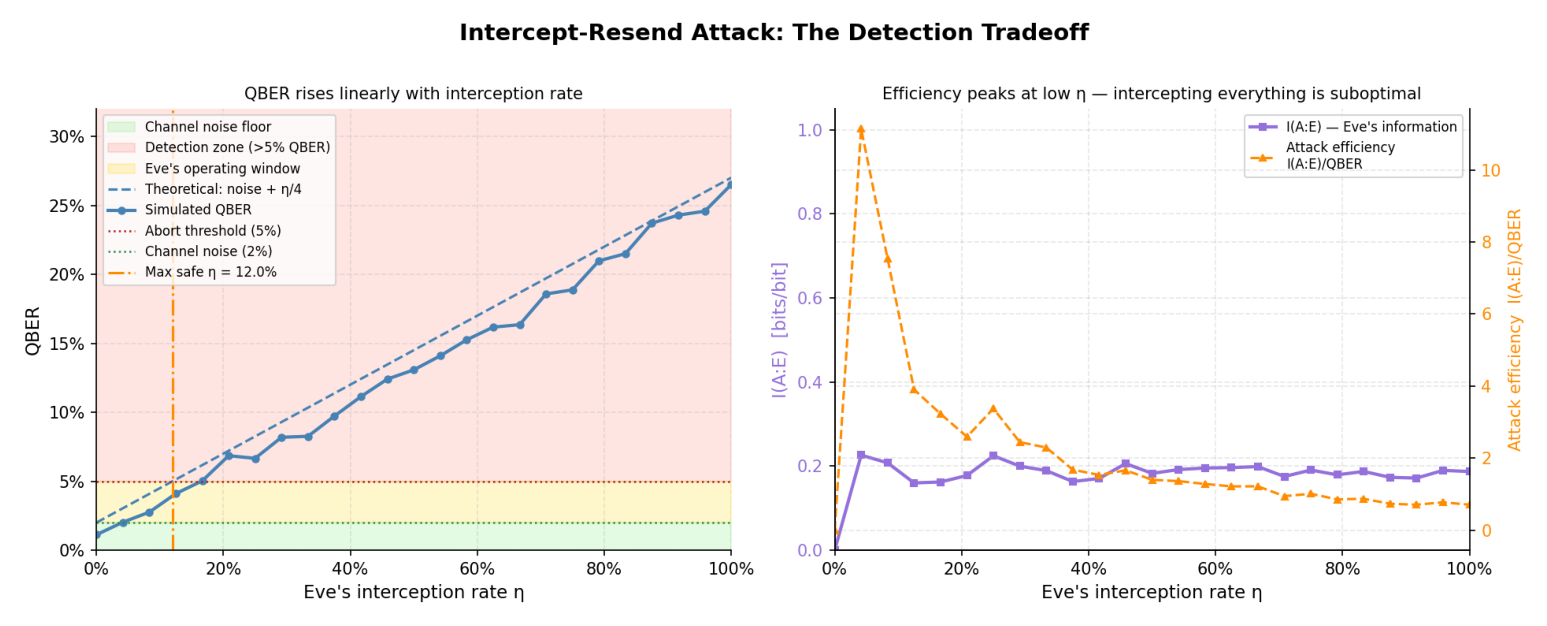

In [11]:
img = mpimg.imread("fig1_intercept_tradeoff.png")
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.imshow(img); ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Detection Threshold Analysis

Given channel noise and a detection threshold, what is Eve's maximum safe interception rate?

**Derivation:**  
QBER_total = noise + η/4  
At threshold: threshold = noise + η_max/4  
Therefore: **η_max = 4 × (threshold − noise)**


In [12]:
print("Detection threshold analysis across noise levels:")
print(f" {'Noise':>8} {'Threshold':>10} {'Max η':>8} {'Eve info at max η':>18}")
print("-" * 55)
for noise in [0.01, 0.02, 0.03, 0.05]:
    for thresh in [0.05, 0.11]:
        d = detection_analysis(noise=noise, threshold=thresh)
        eta_max  = d['max_safe_intercept_rate']
        eve_info = d['eve_info_at_max_rate']
        print(f"  {noise:>8.0%}  {thresh:>10.0%}  {eta_max:>8.1%}  {eve_info:>18.4f} bits/bit")
    print()


Detection threshold analysis across noise levels:
    Noise  Threshold    Max η  Eve info at max η
-------------------------------------------------------
        1%          5%     16.0%              0.0800 bits/bit
        1%         11%     40.0%              0.2000 bits/bit

        2%          5%     12.0%              0.0600 bits/bit
        2%         11%     36.0%              0.1800 bits/bit

        3%          5%      8.0%              0.0400 bits/bit
        3%         11%     32.0%              0.1600 bits/bit

        5%          5%      0.0%              0.0000 bits/bit
        5%         11%     24.0%              0.1200 bits/bit



## 4. Photon Number Splitting (PNS) Attack

This is what breaks *practical* QKD.

**Left:** Poisson distribution of photon number for different μ values.  
At μ=0.1, ~90.5% of pulses are vacuum (n=0), ~9% are single-photon (n=1), ~0.5% have n≥2.  
Eve only needs to target that 0.5%.

**Right:** Eve's information gain vs μ.  
The QBER line stays flat — this attack introduces **zero** detectable errors.


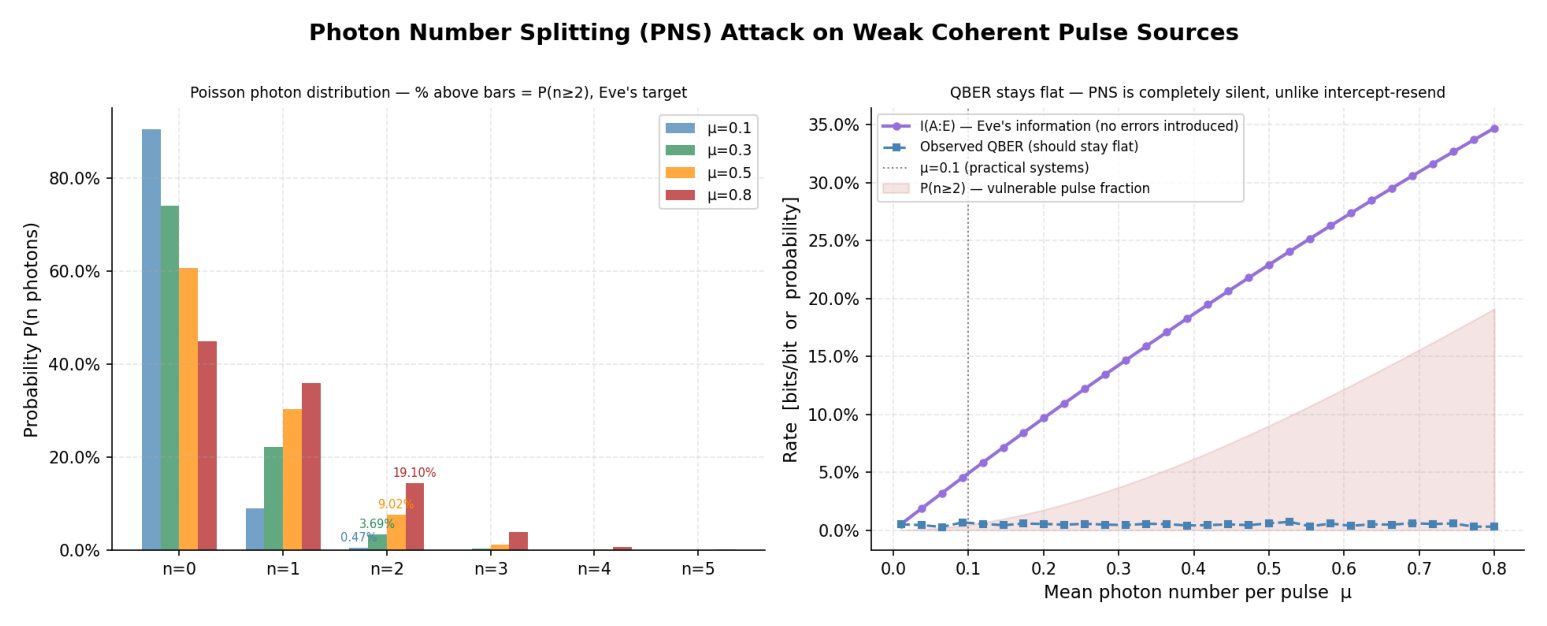

Photon number distribution at mu=0.1:
  n=0: 90.4837%  ████████████████████████████████████████████████████████████████████████
  n=1: 9.0484%  ███████
  n=2: 0.4524%  
  n=3: 0.0151%  
  n=4: 0.0004%  
Multi-photon fraction (vulnerable to PNS): 0.4679%
Eve's info from PNS at mu=0.1: 4.9167% bits/sifted bit


In [13]:
img = mpimg.imread("fig2_pns_analysis.png")
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.imshow(img); ax.axis("off")
plt.tight_layout()
plt.show()

# Photon statistics at mu=0.1
mu = 0.1
dist = PNS.photon_number_distribution(mu, max_n=4)
print(f"Photon number distribution at mu={mu}:")
for n, p in dist.items():
    bar = "█" * int(p * 80)
    print(f"  n={n}: {p:.4%}  {bar}")
print(f"Multi-photon fraction (vulnerable to PNS): {PNS.multi_photon_probability(mu):.4%}")
print(f"Eve's info from PNS at mu=0.1: {PNS.information_per_key_bit(mu):.4%} bits/sifted bit")


## 5. Theory vs Practice: The Full Picture


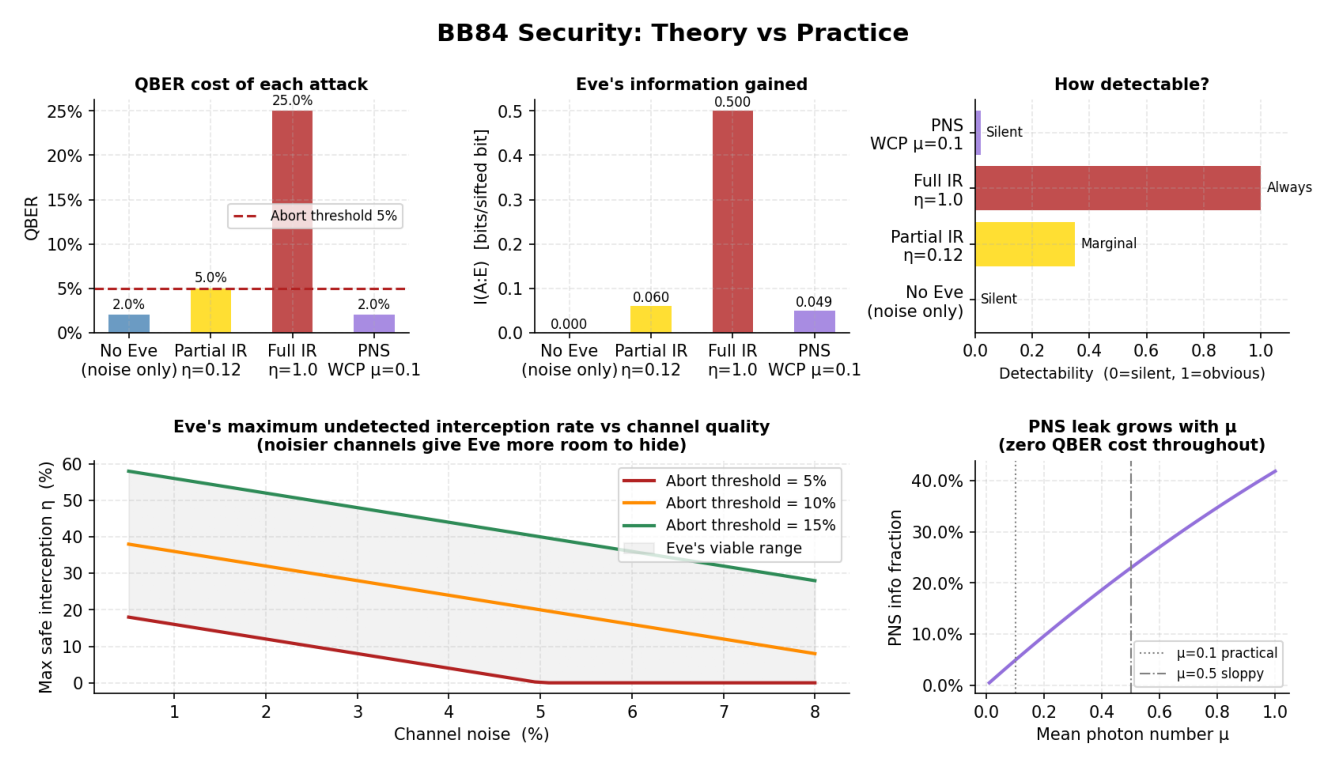

In [14]:
img = mpimg.imread("fig3_theory_vs_practice.png")
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.imshow(img); ax.axis("off")
plt.tight_layout()
plt.show()


## 6. Conclusions

### What this analysis shows

1. **Intercept-resend has a hard detection floor.** Any η > 0 introduces QBER proportional to η/4. Against a 2% noise channel with 5% threshold, Eve's ceiling is η=12% — small but nonzero.

2. **PNS breaks the security argument entirely for WCP sources.** At μ=0.1, ~0.5% of pulses carry 2+ photons. Eve gets perfect information on those bits, silently, with zero QBER contribution. The number is small but the principle is broken.

3. **The fix is the decoy state protocol (Lo, Ma, Chen 2005).** Alice sends pulses at multiple random μ values. Eve cannot apply PNS without distorting the statistics across intensity levels. This makes PNS detectable and restores security.

4. **The real-world lesson:** Security proofs for quantum cryptography are as dependent on the physical implementation as on the mathematical protocol. A perfect protocol running on imperfect hardware can be silently compromised.

### Connection to graphene QKD

Single-photon sources based on quantum dots — including graphene quantum dots — would eliminate the WCP vulnerability entirely by producing exactly one photon per pulse (Fock states). This is one reason solid-state quantum emitters are an active research area alongside quantum computing.

### References

- Bennett, C.H. & Brassard, G. (1984). *Quantum Cryptography: Public Key Distribution and Coin Tossing.*
- Huttner, B. et al. (1995). *Quantum Cryptography with Coherent States.* PRA 51, 1863.
- Lo, H.-K., Ma, X. & Chen, K. (2005). *Decoy State Quantum Key Distribution.* PRL 94, 230504.
